# Burn severity assessment of the Rhodes wildfire (Greece, 2023)

**Note:** This example is based on the _Introduction to Geospatial Raster and Vector Data with Python_ tutorial available [here](https://carpentries-incubator.github.io/geospatial-python/).

## Settings

### Packages

In [4]:
pkgs <- c("rstac", "sf", "lubridate", "terra", "dplyr", "tidyterra", "ggplot2")
invisible(lapply(pkgs, FUN = library, character.only = TRUE))

Linking to GEOS 3.13.0, GDAL 3.10.2, PROJ 9.5.1; sf_use_s2() is TRUE

Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union

terra 1.8.42

Attaching package: ‘dplyr’

The following objects are masked from ‘package:terra’:

    intersect, union

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘tidyterra’

The following object is masked from ‘package:stats’:

    filter



### Plotting options

In [2]:
options(repr.plot.width  =   8,
        repr.plot.height =  12,
        repr.plot.res    = 150)

theme_set(
  theme_bw() +
  theme(plot.title = element_text(size = 12, face = "bold", hjust = 0),
        plot.title.position = "plot",
        strip.text = element_text(size = 10, face = "bold"),
        axis.text = element_text(size = 10),
        axis.title = element_text(size = 10),
        legend.title = element_text(size = 11, face = "bold"),
        legend.text = element_text(size = 11),
        legend.key.width = unit(0.5, "cm"),
        legend.key.height = unit(0.5, "cm"),
        legend.position = "right")
)

pal_sev <- c("#0000ff", "#2eb82c", "#f1dd00", "#fda71d", "#d52903", "#6e01a3")

severity_classes <- data.frame(name = c("Regrowth", "Unburned", "Low",
                                        "Moderate", "High", "Very high"),
                               description = c("Vegetation regrowth", "Little to no damage",
                                               "Minor vegetation loss or early signs of damage",
                                               "Partial vegetation loss",
                                               "Significant vegetation loss",
                                               "Extensive vegetation loss and exposed soil"),
                               lower = c(-Inf, -0.1, 0.1, 0.27, 0.44, 0.66),
                               upper = c(-0.1, 0.1, 0.27, 0.44, 0.66, Inf),
                               color = pal_sev)

### Custom functions

In [3]:
## Convert dates to RFC3339 format
date2rfc3339 <- function(x) format(as_datetime(x), "%Y-%m-%dT%H:%M:%SZ")

## Select and download STAC assets
stac_download <- function(endpoint, collection, limit = 100,
                          start_date, end_date, target_date = NULL,
                          bbox = NULL, roi_path = NULL, thresh_cloud = NULL,
                          asset_names = NULL, out_path = tempdir()) {

    ### Load packages
    library(sf)
    library(rstac)

    ### Format date range
    daterange <- paste(lapply(c(start_date, end_date), FUN = date2rfc3339), collapse = "/")

    ### Perform initial dataset search query
    search <- stac(endpoint) |>
      stac_search(collections = collection,
                  datetime    = daterange,
                  limit       = limit)
    
    if(!is.null(bbox)) { search <- stac_search(search, bbox = bbox) }
    if(!is.null(roi_path)) { search <- stac_search(search, intersects = st_read(roi_path, quiet = TRUE)) }

    ### (Sub)select and fetch items
    items <- post_request(search)
    if(!is.null(thresh_cloud)) {
        items <- post_request(search)
        suppressWarnings(items <- items_filter(items, properties$`eo:cloud_cover` < thresh_cloud))
    }
    items <- items_fetch(items, progress = FALSE)
    if(!is.null(asset_names)) {
        items <- assets_select(items, asset_names = asset_names)
    }
    if(!is.null(target_date)) {
        target_date <- date2rfc3339(target_date)
        items <- items_select(items, selection = which(items_datetime(items) == as.Date(target_date)))
    }

    ### Download assets
    assets_json <- assets_download(items       = items,
                                   asset_names = asset_names,
                                   output_dir  = out_path,
                                   overwrite   = TRUE,
                                   use_gdal    = FALSE,
                                   progress    = FALSE)
}

### Parameters

In [4]:
## STAC endpoint URL
cons_endpoint <- "https://earth-search.aws.element84.com/v1"

## Dataset collection ID
param_collection <- "sentinel-2-l2a"

## Path to the file defining the region-of-interest
param_roi_path <- "data/rois/wf_rhodes_2023.gpkg"

## Target coordinate reference system code
param_crs_t <- "EPSG:32635"

## Start and end dates
param_date_start <- "2023-07-01"
param_date_end <- "2023-08-31"

## Pre- and post-fire dates
param_date_pre <- "2023-07-08"
param_date_post <- "2023-08-27"

## Cloud cover threshold
param_thresh_cloud <- 30

## Asset codes
param_bands <- c("nir08", "swir22")

## Path to the directory to save outputs
param_dir_out <- tempdir()
if (!dir.exists(param_dir_out)) dir.create(param_dir_out)

## Region of interest

### Import and reproject boundaries

In [5]:
## Rhodes
rhodes <- "data/rois/rhodes.gpkg" |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))
rhodes_sv <- project(vect(rhodes), param_crs_t)

## Burned area
roi <- param_roi_path |>
  st_read(quiet = TRUE) |>
  st_as_sf() |>
  st_transform(crs = st_crs(4326))
roi_sv <- project(vect(roi), param_crs_t)
roi_area <- roi$AREA_HA

### Visualize region of interest

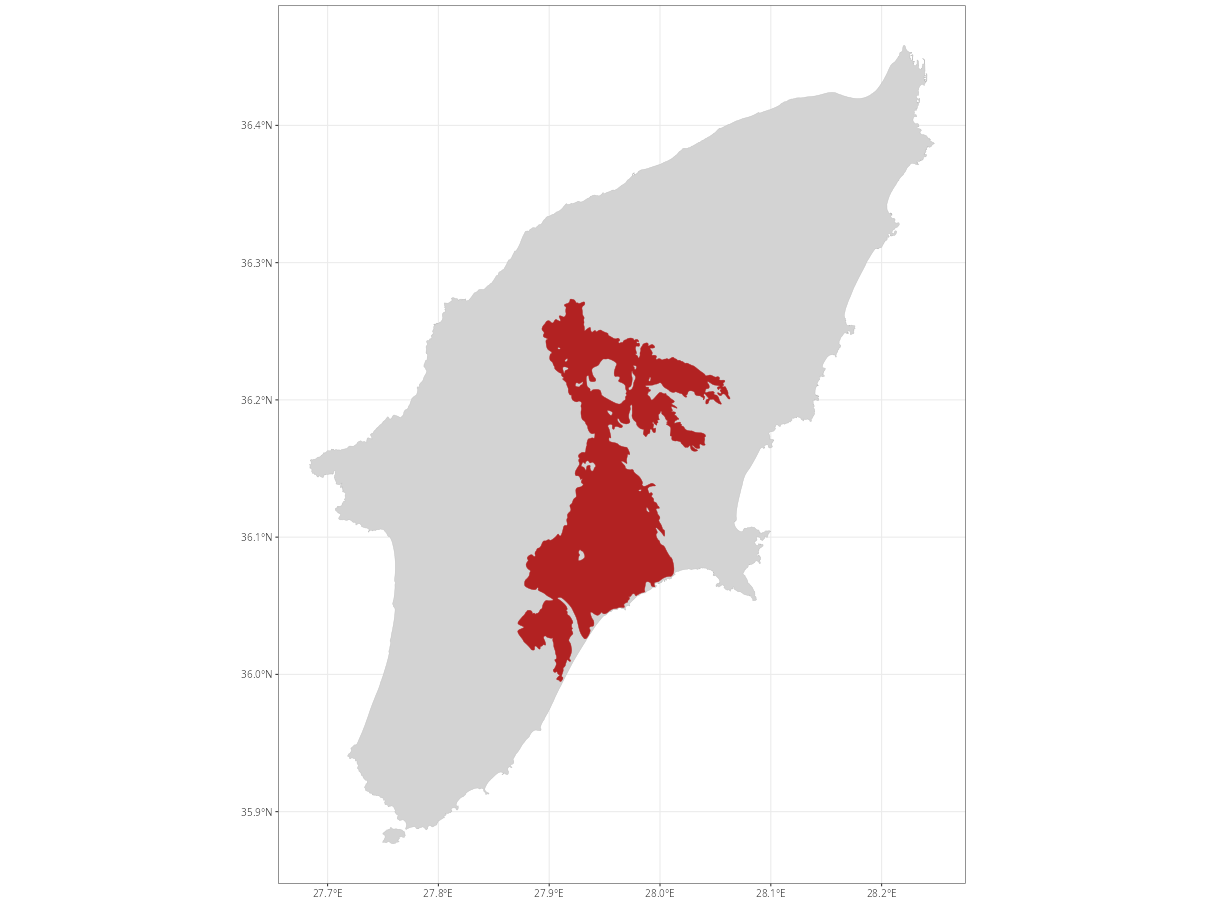

In [6]:
ggplot() +
  geom_sf(data = st_geometry(rhodes), fill = "lightgray", color = "gray") +
  geom_sf(data = st_geometry(roi), fill = "firebrick", color = "firebrick") +
  coord_sf(datum = st_crs(4326))

## Data downloading

### Select and download pre-fire images

In [7]:
# STAC Download Prefire Image
# NaaVRE:
#  cell:
#   outputs:
#    - dl_files_pre: String
#   cons:
#    - cons_endpoint: String
#   params:
#    - param_collection: String
#    - param_date_start: String
#    - param_date_end: String
#    - param_roi_path: String
#    - param_thresh_cloud: Integer
#    - param_date_pre: String
#    - param_bands: List
#    - param_dir_out: List
#   dependencies:
#    - name: sf
#    - name: rstac
# ...

dl_files_pre <- stac_download(endpoint     = cons_endpoint,
                              collection   = param_collection,
                              limit        = 100,
                              start        = param_date_start,
                              end          = param_date_end,
                              roi_path     = "data/rois/rhodes.gpkg",
                              asset_names  = param_bands,
                              target_date  = param_date_pre,
                              out_path     = param_dir_out)

In [8]:
# List results
items_as_tibble(dl_files_pre)

# A tibble: 3 × 41
  constellation created   datetime earthsearch:boa_offs…¹ earthsearch:payload_…²
  <chr>         <chr>     <chr>    <lgl>                  <chr>                 
1 sentinel-2    2023-07-… 2023-07… TRUE                   roda-sentinel2/workfl…
2 sentinel-2    2023-07-… 2023-07… TRUE                   roda-sentinel2/workfl…
3 sentinel-2    2023-07-… 2023-07… TRUE                   roda-sentinel2/workfl…
# ℹ abbreviated names: ¹​`earthsearch:boa_offset_applied`,
#   ²​`earthsearch:payload_id`
# ℹ 36 more variables: `earthsearch:s3_path` <chr>, `eo:cloud_cover` <dbl>,
#   `grid:code` <chr>, instruments <chr>, `mgrs:grid_square` <chr>,
#   `mgrs:latitude_band` <chr>, `mgrs:utm_zone` <int>, platform <chr>,
#   `processing:software` <list>, `proj:epsg` <int>,
#   `s2:cloud_shadow_percentage` <dbl>, `s2:dark_features_percentage` <dbl>, …

### Select and download pre-fire images

In [9]:
# STAC Download Postfire Image
# NaaVRE:
#  cell:
#   outputs:
#    - dl_files_post: String
#   cons:
#    - cons_endpoint: String
#   params:
#    - param_collection: String
#    - param_date_start: String
#    - param_date_end: String
#    - param_roi_path: String
#    - param_thresh_cloud: Integer
#    - param_date_post: String
#    - param_bands: List
#    - param_dir_out: List
#   dependencies:
#    - name: sf
#    - name: rstac
# ...

dl_files_post <- stac_download(endpoint     = cons_endpoint,
                               collection   = param_collection,
                               limit        = 100,
                               start        = param_date_start,
                               end          = param_date_end,
                               roi_path     = "data/rois/rhodes.gpkg",
                               asset_names  = param_bands,
                               target_date  = param_date_post,
                               out_path     = param_dir_out)

In [10]:
# List results
items_as_tibble(dl_files_post)

# A tibble: 3 × 41
  constellation created   datetime earthsearch:boa_offs…¹ earthsearch:payload_…²
  <chr>         <chr>     <chr>    <lgl>                  <chr>                 
1 sentinel-2    2023-08-… 2023-08… TRUE                   roda-sentinel2/workfl…
2 sentinel-2    2023-08-… 2023-08… TRUE                   roda-sentinel2/workfl…
3 sentinel-2    2023-08-… 2023-08… TRUE                   roda-sentinel2/workfl…
# ℹ abbreviated names: ¹​`earthsearch:boa_offset_applied`,
#   ²​`earthsearch:payload_id`
# ℹ 36 more variables: `earthsearch:s3_path` <chr>, `eo:cloud_cover` <dbl>,
#   `grid:code` <chr>, instruments <chr>, `mgrs:grid_square` <chr>,
#   `mgrs:latitude_band` <chr>, `mgrs:utm_zone` <int>, platform <chr>,
#   `processing:software` <list>, `proj:epsg` <int>,
#   `s2:cloud_shadow_percentage` <dbl>, `s2:dark_features_percentage` <dbl>, …

## List downloaded files

### List all downloaded files

In [11]:
dl_files <- list.files(path = param_dir_out,
                       pattern = "*.tif",
                       full.names = TRUE,
                       recursive = TRUE)
print(dl_files)

 [1] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif"
 [2] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif"
 [3] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif"
 [4] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif"
 [5] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif"
 [6] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif"
 [7] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif"
 [8] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif"
 [9] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif"
[10] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif"
[11] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L

### Build table with all properties

In [12]:
dl_files_sep <- strsplit(dl_files, split = "/")
dl_files_df <- cbind(dl_files, as.data.frame(do.call(rbind, lapply(dl_files_sep, rbind))))
names(dl_files_df) <- c("path", "root", "dir", "subdir", "collection", "zone",
                        "area", "tile", "year", "month", "name", "band")
dl_files_df

                                                                                   path
1  /tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif
2  /tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif
3  /tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif
4  /tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif
5  /tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif
6  /tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif
7  /tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif
8  /tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif
9  /tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif
10 /tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif
11 /tmp/Rtmp297TzE/sentinel-s2-l

### Apply grouping to pre-fire images

In [13]:
pre_list <- filter(dl_files_df, month == "7")
print(pre_list$path)

[1] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B12.tif"
[2] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/7/S2A_35SNA_20230708_0_L2A/B8A.tif"
[3] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B12.tif"
[4] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/7/S2A_35SNV_20230708_0_L2A/B8A.tif"
[5] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B12.tif"
[6] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/PA/2023/7/S2A_35SPA_20230708_0_L2A/B8A.tif"


### Apply grouping to post-fire images

In [14]:
post_list <- filter(dl_files_df, month == "8")
print(post_list$path)

[1] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B12.tif"
[2] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NA/2023/8/S2A_35SNA_20230827_0_L2A/B8A.tif"
[3] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B12.tif"
[4] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/NV/2023/8/S2A_35SNV_20230827_0_L2A/B8A.tif"
[5] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A/B12.tif"
[6] "/tmp/Rtmp297TzE/sentinel-s2-l2a-cogs/35/S/PA/2023/8/S2A_35SPA_20230827_0_L2A/B8A.tif"


## Image preprocessing

### Mosaic (merge) different tiles

The three scenes/tiles have to be merged into one image for each of pre- and post-fire:

In [15]:
## Merge tiles for pre-fire images
s2_pre_path <- paste0(param_dir_out, "/s2_pre.tif")
merge(x = rast(filter(pre_list, tile == "NA")$path),
      y = rast(filter(pre_list, tile == "NV")$path),
      z = rast(filter(pre_list, tile == "PA")$path),
      filename = s2_pre_path, overwrite = TRUE)
gc()

          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 1887763 100.9    3619007 193.3  3619007 193.3
Vcells 3280723  25.1    8388608  64.0  6094538  46.5

In [16]:
## Merge tiles for post-fire images
s2_post_path <- paste0(param_dir_out, "/s2_post.tif")
merge(x = rast(filter(post_list, tile == "NA")$path),
      y = rast(filter(post_list, tile == "NV")$path),
      z = rast(filter(post_list, tile == "PA")$path),
      filename = s2_post_path, overwrite = TRUE)
gc()

          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 1888130 100.9    3619007 193.3  3619007 193.3
Vcells 3281910  25.1    8388608  64.0  6094538  46.5

### Crop pre-fire image

In [17]:
s2_pre_path_c <- paste0(param_dir_out, "/s2_pre_c.tif")
crop(x = rast(s2_pre_path), y = rhodes_sv, mask = TRUE,
     filename = s2_pre_path_c, overwrite = TRUE)
gc()

          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 1887505 100.9    3619007 193.3  3619007 193.3
Vcells 3281308  25.1    8388608  64.0  6094538  46.5

SpatRaster resampled to ncells = 500269


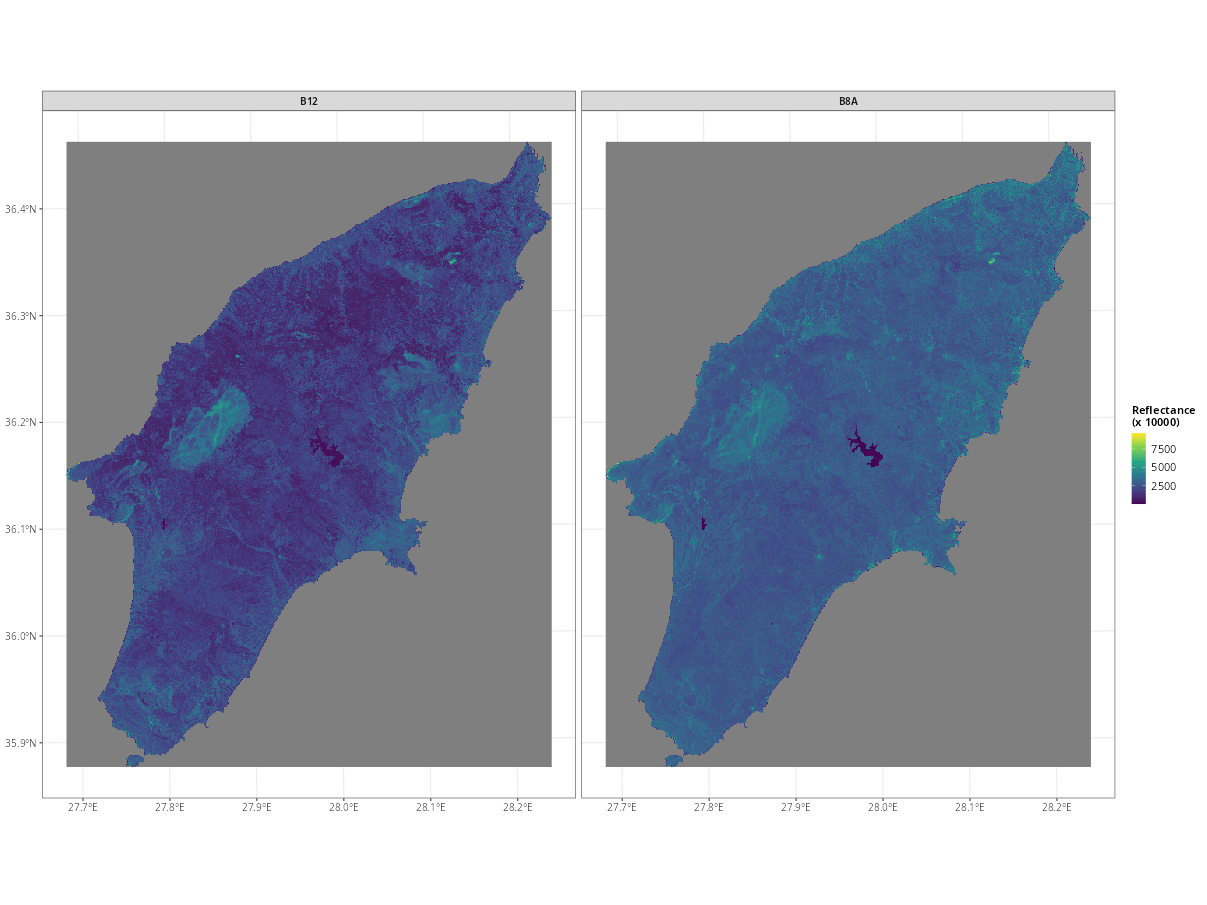

In [18]:
ggplot() +
  geom_spatraster(data = rast(s2_pre_path_c)) +
  scale_fill_viridis_c() +
  facet_wrap(~ lyr) +
  labs(fill = "Reflectance\n(x 10000)")

### Crop post-fire image

In [19]:
s2_post_path_c <- paste0(param_dir_out, "/s2_post_c.tif")
crop(x = rast(s2_post_path), y = rhodes_sv, mask = TRUE,
     filename = s2_post_path_c, overwrite = TRUE)
gc()

          used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells 2033790 108.7    3619007 193.3  3619007 193.3
Vcells 5810996  44.4   39081028 298.2 48851284 372.8

SpatRaster resampled to ncells = 500269


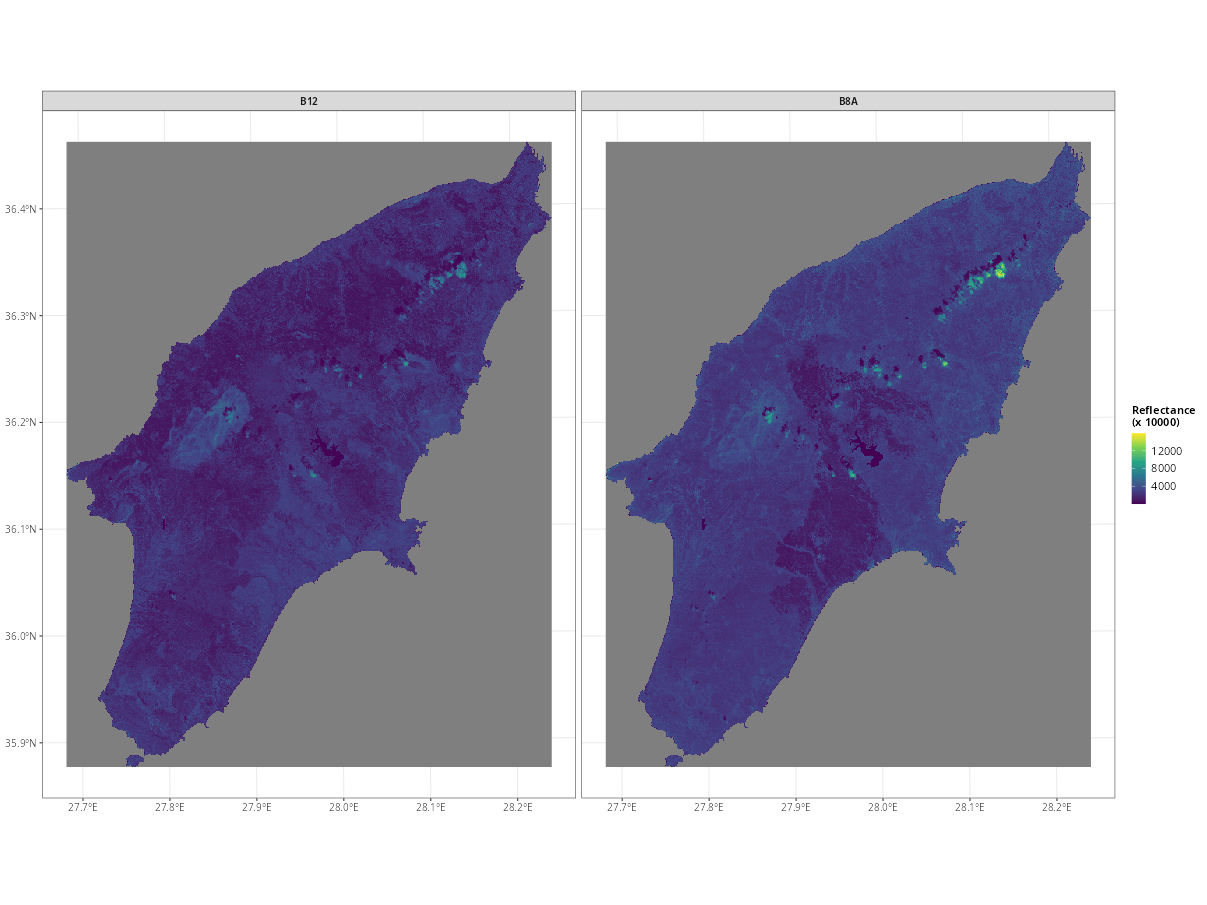

In [20]:
ggplot() +
  geom_spatraster(data = rast(s2_post_path_c)) +
  scale_fill_viridis_c() +
  facet_wrap(~ lyr) +
  labs(fill = "Reflectance\n(x 10000)")

## Burn severity assessment

The Normalized Burn Ratio (NBR) can be calculated, from the Sentinel-2 bands 8 (near-infrared, NIR) and 12 (shortwave-infrared, SWIR), using the following expression:

$`NBR = {(NIR - SWIR) \over{(NIR + SWIR)}}`$

### Compute pre-fire NBR

In [21]:
s2_pre_path_nbr <- paste0(param_dir_out, "/s2_pre_nbr.tif")
lapp(x = rast(s2_pre_path_c),
     fun = \(B8A, B12) ((B8A - B12) / (B8A + B12)),
     usenames = TRUE, cores = 3,
     filename = s2_pre_path_nbr, overwrite = TRUE)
gc()

           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  2064904 110.3   13680384 730.7 10287971 549.5
Vcells 17009054 129.8   81901222 624.9 85246958 650.4

### Compute post-fire NBR

In [22]:
s2_post_path_nbr <- paste0(param_dir_out, "/s2_post_nbr.tif")
lapp(x = rast(s2_post_path_c),
     fun = \(B8A, B12) ((B8A - B12) / (B8A + B12)),
     usenames = TRUE, cores = 3,
     filename = s2_post_path_nbr, overwrite = TRUE)
gc()

           used  (Mb) gc trigger  (Mb) max used  (Mb)
Ncells  2065171 110.3   11104164 593.1 10287971 549.5
Vcells 17010799 129.8   94491008 721.0 98361370 750.5

### Visualize NBR maps

In [23]:
s2_nbr <- c(rast(s2_pre_path_nbr), rast(s2_post_path_nbr))
names(s2_nbr) <- c("Pre-fire NBR", "Post-fire NBR")

SpatRaster resampled to ncells = 500269


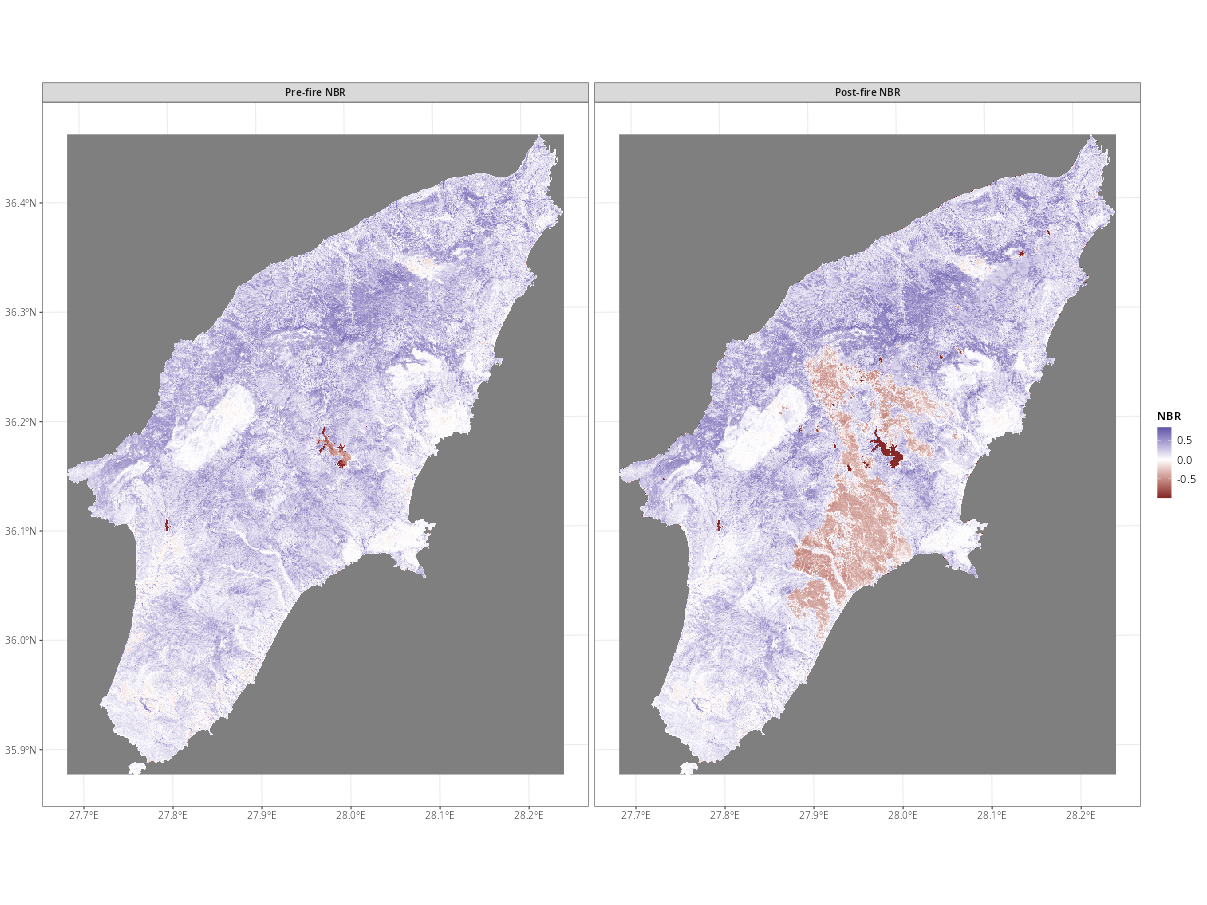

In [24]:
ggplot() +
  geom_spatraster(data = s2_nbr) +
  scale_fill_gradient2() +
  facet_wrap(~ lyr) +
  labs(fill = "NBR")

### Calculate dNBR

Burn severity can be mapped using Delta-NBR, calculated as follows:

$`dNBR = {NBR_{pre} - NBR_{post}}`$

In [25]:
s2_dnbr_path <- paste0(param_dir_out, "/s2_dnbr.tif")
xapp(x = rast(s2_pre_path_nbr), y = rast(s2_post_path_nbr),
     fun = \(x, y) (x - y), filename = s2_dnbr_path, overwrite = TRUE)
gc()

           used  (Mb) gc trigger   (Mb) max used   (Mb)
Ncells  2080545 111.2   26142169 1396.2 32677711 1745.2
Vcells 19061336 145.5   75989921  579.8 98361370  750.5

In [26]:
s2_dnbr <- rast(s2_dnbr_path) |>
  crop(buffer(roi_sv, 1000), mask = FALSE)
names(s2_dnbr) <- "dNBR"

s2_dnbr_c <- clamp(s2_dnbr, lower = -0.25, upper = 2)

SpatRaster resampled to ncells = 501270


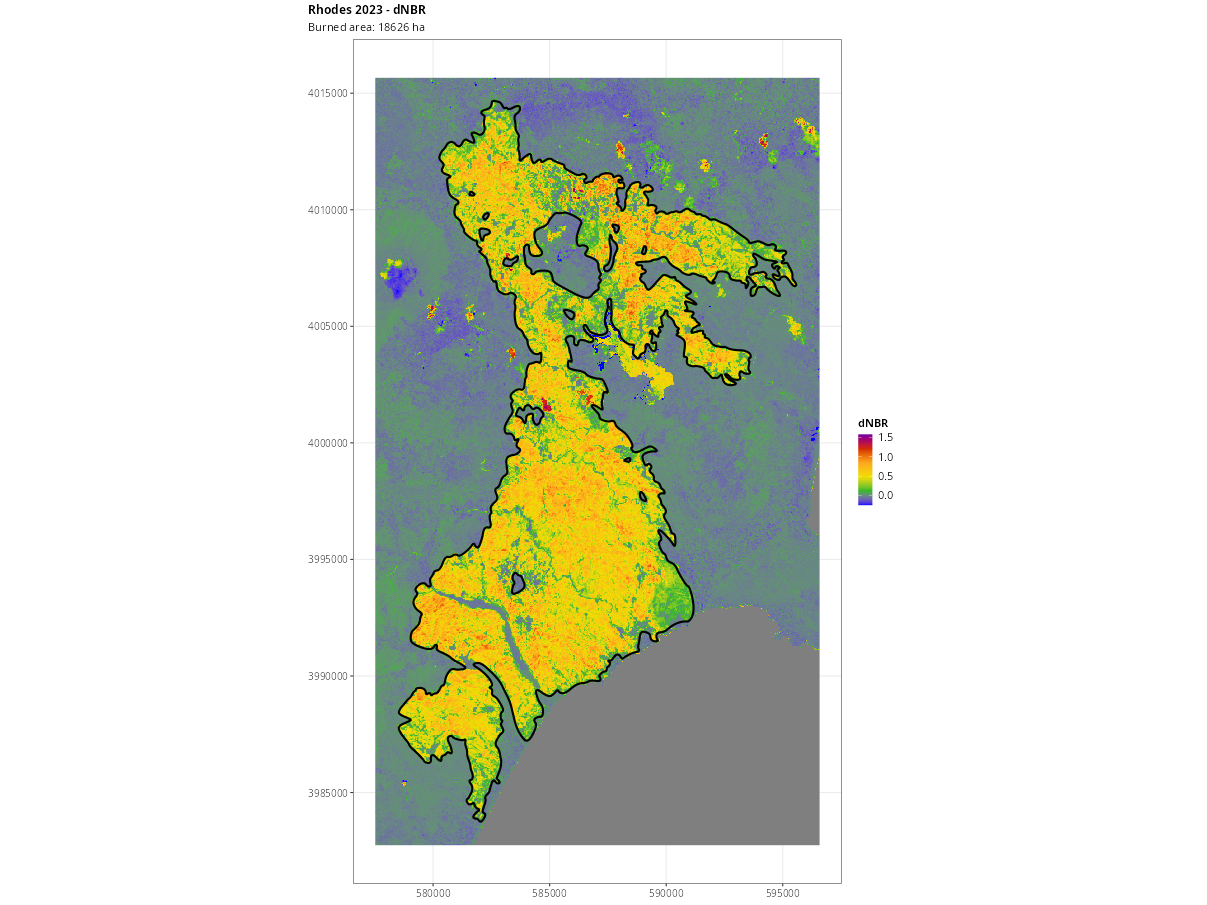

In [35]:
gg_dnbr <- ggplot() +
  geom_spatraster(data = s2_dnbr_c) +
  geom_spatvector(data = roi_sv, color = "black", fill = "transparent", linewidth = 1) +
  coord_sf(datum = st_crs(32635)) +
  scale_fill_gradientn(colors = pal_sev) +
  labs(title = "Rhodes 2023 - dNBR", fill = "dNBR",
       subtitle = paste("Burned area:", roi_area, "ha"))

ggsave(plot = gg_dnbr,
       device = "png",
       filename = "out/figures/s2-dnbr_rhodes2023.png",
       width = 16,
       height = 23,
       units = "cm",
       dpi = "print")

print(gg_dnbr)

## Classify burn severity

Delta Normalized Burn Ratio (dNBR) classes derived from Sentinel-2 imagery quantify wildfire and burn severity by calculating the difference between pre- and post-fire Normalized Burn Ratio (NBR) values.

These categories are mapped according to standard thresholds initially defined by the USGS and Monitoring Trends in Burn Severity (MTBS) programs.

The standard dNBR severity classification ranges are generally divided as follows:

| Burn Severity Class | dNBR Value Range | Description                                                  |
| :------------------ | ---------------: | :----------------------------------------------------------- |
| Enhanced Regrowth   |         < -0.100 | High post-fire vegetation productivity or new growth.        |
| Unburned            | -0.100 to +0.100 | Minimal or no change to vegetation cover.                    |
| Low Severity        | +0.101 to +0.269 | Scorched understory, minimal canopy tree mortality.          |
| Moderate Severity   | +0.270 to +0.439 | Partial canopy scorch, mixed severity.                       |
| High Severity       | +0.440 to +0.659 | Widespread canopy consumption or heavy charring.             |
| Very High Severity  | > 0.659          | Complete consumption of overstory and understory vegetation. |

### Map burn severity classes

In [28]:
s2_sev <- s2_dnbr |>
  crop(roi_sv, mask = TRUE) |>
  mutate(sev = cut(dNBR, breaks = c(-Inf, severity_classes$upper),
                         labels = severity_classes$name))

SpatRaster resampled to ncells = 501278


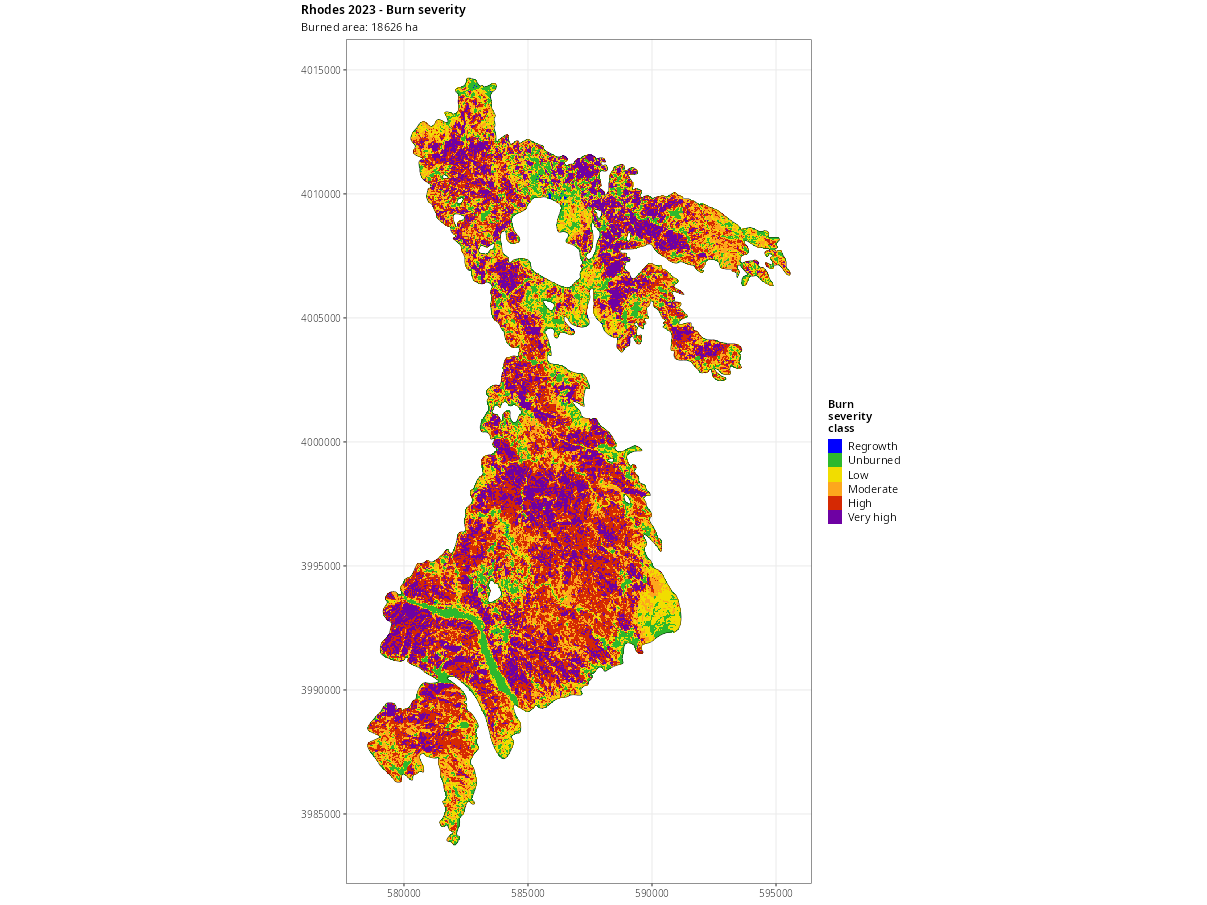

In [36]:
gg_dnbr_class <- ggplot() +
  geom_spatraster(data = s2_sev[["sev"]]) +
  geom_spatvector(data = roi_sv, color = "black", fill = "transparent") +
  coord_sf(datum = st_crs(32635)) +
  scale_fill_manual(values = severity_classes$color, na.translate = FALSE) +
  labs(title = "Rhodes 2023 - Burn severity", fill = "Burn\nseverity\nclass",
       subtitle = paste("Burned area:", roi_area, "ha"))

ggsave(plot = gg_dnbr_class,
       device = "png",
       filename = "out/figures/s2-dnbr_rhodes2023_classified.png",
       width = 16,
       height = 23,
       units = "cm",
       dpi = "print")

print(gg_dnbr_class)